# Mock EEG / Neuropsychological dataset

Generate a realistic simulated dataset for EEG and neuropsychological research.
Includes age, education, P300 latency (event-related potential), and APACS scores
with controlled effect sizes and correlations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Parameters

Tweak these values to control sample size, effect sizes, and population characteristics.
All relationships between variables are defined here.

In [5]:
n = 40

# --- R2 targets ---
R2_LATENT = 0.50
R2_ERP    = 0.35
R2_TEST   = 0.50

# Age (normal, centred ~67)
age_mean, age_sd = 67, 7
age_lo, age_hi = 50, 85

# Sex (Bernoulli)
sex_p = 0.5

# Lesion severity (exponential, right-skewed: mild more common)
severity_mean = 3
severity_min, severity_max = 0, 10

# Education (categorical)
edu_values = [5, 8, 13, 16, 18, 22]
edu_p = [.10, .21, .34, .12, .15, .08]

# CRIq ~ N(100, 15), corr +edu, -age
criq_mean, criq_sd = 100, 15
criq_beta_edu = 0.30
criq_beta_age = -0.15
criq_min, criq_max = 70, 130

# Latent -> ERP coefficients
beta_ling_n400a  =  0.80
beta_ling_n400l  = -0.70
beta_attn_p300a  =  0.80
beta_attn_p300l  = -0.70
beta_age_n400l   =  0.30
beta_age_p300l   =  0.30

# ERP mean/sd (pre-clip)
n400a_mean, n400a_sd = 3.5, 1.2
n400l_mean, n400l_sd = 425, 30
p300a_mean, p300a_sd = 12.5, 3.5
p300l_mean, p300l_sd = 375, 30

# ERP clip ranges
n400a_lo, n400a_hi = 1, 6
n400l_lo, n400l_hi = 350, 500
p300a_lo, p300a_hi = 5, 20
p300l_lo, p300l_hi = 300, 450

# Cognitive test targets (standardised betas)
# APACS ~ - n400_lat + n400_amp + criq - age + sesso
apacs_beta = { 
    'n400_lat': -0.30, 
    'n400_amp': 0.18, 
    'criq': 0.30, 
    'age': -0.35, 
    'sex': 0.0}
apacs_mean, apacs_sd = 0.75, 0.05
apacs_lo, apacs_hi = 0, 1

# Attentive Matrix ~ p300_lat + p300_amp + criq + age + sesso
matrix_beta = {
    'p300_lat': -0.32, 
    'p300_amp': 0.30, 
    'criq': 0.30, 
    'age': -0.35, 
    'sex': 0.0}
matrix_mean, matrix_sd = 40, 8
matrix_lo, matrix_hi = 0, 60

# MoCA ~ n400_lat + n400_amp + p300_lat + p300_amp + criq + eta + sesso
moca_beta = {
    'n400_lat': -0.05, 
    'n400_amp': 0.05, 
    'p300_lat': -0.05, 
    'p300_amp': 0.05,
    'criq': 0.30, 
    'age': -0.35, 
    'sex': 0.0}
moca_mean, moca_sd = 24, 3
moca_lo, moca_hi = 0, 30

## Randomness

Each variable uses an independent random number generator with a different seed.
Using the same seed for all would create spurious correlations, since every
variable would draw from the identical pseudo-random sequence.

In [6]:
seed = 42

rng_age     = np.random.default_rng(seed)
rng_sex     = np.random.default_rng(seed+1)
rng_severity= np.random.default_rng(seed+2)
rng_edu     = np.random.default_rng(seed+3)
rng_criq    = np.random.default_rng(seed+4)
rng_ling    = np.random.default_rng(seed+5)
rng_attn    = np.random.default_rng(seed+6)
rng_P300    = np.random.default_rng(seed+7)
rng_N400    = np.random.default_rng(seed+8)
rng_apacs   = np.random.default_rng(seed+9)
rng_matrix  = np.random.default_rng(seed+10)
rng_moca    = np.random.default_rng(seed+11)


## Simulation

### Age

Defined as a normal distribution with `age_mean` and `age_sd`

In [7]:
float_age = rng_age.normal(loc=age_mean, scale=age_sd, size=n)
age = np.round(float_age).astype(int)
age = np.clip(age, age_lo, age_hi)

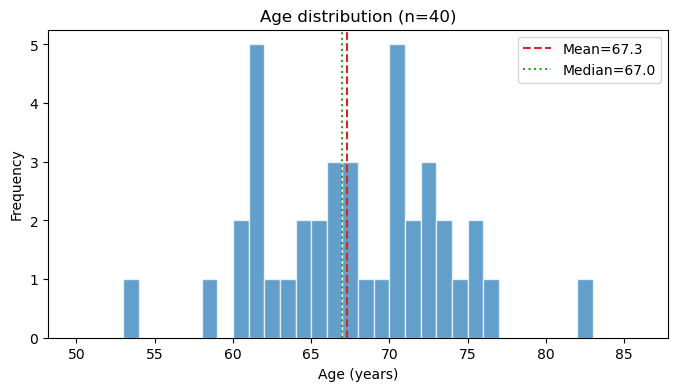

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(age, bins=range(age_lo, age_hi + 2), edgecolor='white', alpha=0.7)
plt.axvline(np.mean(age), color='C3', ls='--', label=f'Mean={np.mean(age):.1f}')
plt.axvline(np.median(age), color='C2', ls=':', label=f'Median={np.median(age):.1f}')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title(f'Age distribution (n={n})')
plt.legend()
plt.show()

### Education

Randomly sampled from the possible `edu_values` with probabilities `edu_p`.

Education is independent of age.

In [9]:
education = rng_edu.choice(edu_values, size=n, p=edu_p)

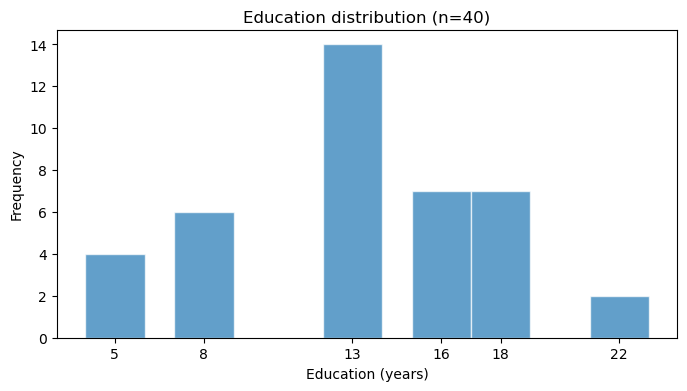

In [10]:
uniq, counts = np.unique(education, return_counts=True)
count_map = dict(zip(uniq, counts))
edu_counts = [count_map.get(v, 0) for v in edu_values]

plt.figure(figsize=(8, 4))
plt.bar(edu_values, edu_counts, width=2, edgecolor='white', alpha=0.7)
plt.xticks(edu_values)
plt.xlabel('Education (years)')
plt.ylabel('Frequency')
plt.title(f'Education distribution (n={n})')
plt.show()


### Sex

Random binary variable (0 = female, 1 = male) with probability `sex_p`.


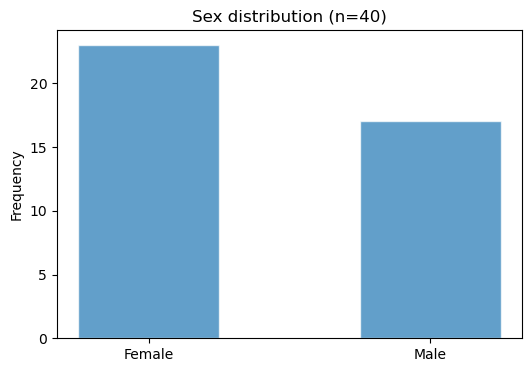

In [11]:
sex = rng_sex.binomial(1, sex_p, n).astype(float)

plt.figure(figsize=(6, 4))
counts = [(sex == 0).sum(), (sex == 1).sum()]
plt.bar(['Female', 'Male'], counts, width=0.5, edgecolor='white', alpha=0.7)
plt.ylabel('Frequency')
plt.title(f'Sex distribution (n={n})')
plt.show()


### Lesion severity

Right-skewed exponential distribution: mild strokes more common than severe.


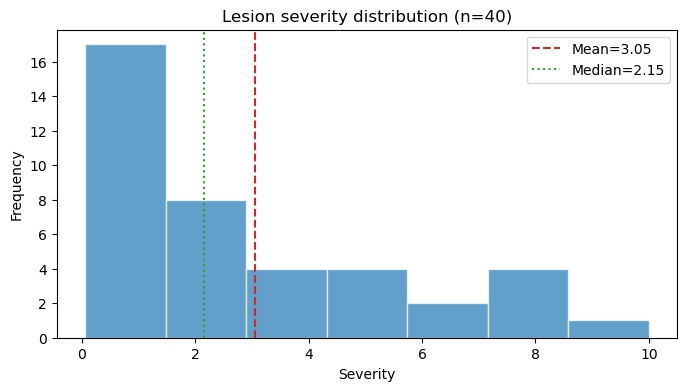

In [12]:
severity = rng_severity.exponential(scale=severity_mean, size=n)
severity = np.clip(severity, severity_min, severity_max)

plt.figure(figsize=(8, 4))
plt.hist(severity, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(severity), color='C3', ls='--', label=f'Mean={np.mean(severity):.2f}')
plt.axvline(np.median(severity), color='C2', ls=':', label=f'Median={np.median(severity):.2f}')
plt.xlabel('Severity')
plt.ylabel('Frequency')
plt.title(f'Lesion severity distribution (n={n})')
plt.legend()
plt.show()


### CRIq

Cognitive Reserve Index questionnaire.
~N(100, 15), positively correlated with education (+0.30),
negatively correlated with age (−0.15).


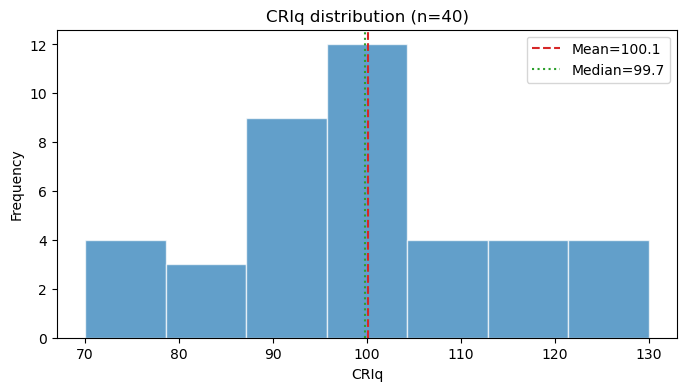

In [13]:
z_criq = rng_criq.normal(0, 1, n)
z_criq = z_criq + criq_beta_edu * (education - np.mean(education)) / np.std(education, ddof=1)
z_criq = z_criq + criq_beta_age * (age - np.mean(age)) / np.std(age, ddof=1)
criq = criq_mean + criq_sd * (z_criq - np.mean(z_criq)) / np.std(z_criq, ddof=1)
criq = np.clip(criq, criq_min, criq_max)

plt.figure(figsize=(8, 4))
plt.hist(criq, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(criq), color='C3', ls='--', label=f'Mean={np.mean(criq):.1f}')
plt.axvline(np.median(criq), color='C2', ls=':', label=f'Median={np.median(criq):.1f}')
plt.xlabel('CRIq')
plt.ylabel('Frequency')
plt.title(f'CRIq distribution (n={n})')
plt.legend()
plt.show()


### Latent abilities (not exported)

Two hidden variables mediating the effect of lesion severity and age
on ERP markers and cognitive scores.


In [14]:
def standardize(x):
    return (x - np.mean(x)) / np.std(x, ddof=1)

# Language ability: driven negatively by severity and age
z_ling = -0.70 * standardize(severity) - 0.20 * standardize(age)
abilita_linguaggio = (z_ling / np.std(z_ling, ddof=1) * np.sqrt(R2_LATENT)
                      + rng_ling.normal(0, np.sqrt(1 - R2_LATENT), n))

# Attention ability: driven negatively by severity and age
z_attn = -0.70 * standardize(severity) - 0.20 * standardize(age)
abilita_attenzione = (z_attn / np.std(z_attn, ddof=1) * np.sqrt(R2_LATENT)
                      + rng_attn.normal(0, np.sqrt(1 - R2_LATENT), n))

print(f'Language:  mean={np.mean(abilita_linguaggio):.3f}, sd={np.std(abilita_linguaggio, ddof=1):.3f}')
print(f'Attention: mean={np.mean(abilita_attenzione):.3f}, sd={np.std(abilita_attenzione, ddof=1):.3f}')


Language:  mean=-0.113, sd=1.114
Attention: mean=0.217, sd=0.996


### Helper function

Function to generate outcomes with exact target betas and R².


In [15]:
def make_linear_exact(predictors, betas, rng, r2):
    '''Generate outcome y such that OLS of y on predictors yields
    exactly the target standardised betas with exactly target R2.
    '''
    # 1. Standardise each predictor → X matrix (n x k), mean=0, var=1
    X = np.column_stack([standardize(predictors[k]) for k in betas])
    n, k = len(X), len(betas)
    # 2. Systematic component: y_sys = X @ b   (exact betas, R2=1)
    b = np.array([betas[k] for k in betas])
    y_sys = X @ b
    var_sys = np.var(y_sys, ddof=1)
    if var_sys < 1e-12:
        return rng.normal(0, 1, n)
    # 3. Noise variance needed to lower R2 from 1.0 to target r2
    var_total = var_sys / r2
    var_noise = var_total - var_sys
    # 4. Build noise that is orthogonal to X (including intercept)
    #    This keeps the OLS coefficients exactly = b in every draw.
    Xc = np.column_stack([np.ones(n), X])          # add intercept column
    P = Xc @ np.linalg.inv(Xc.T @ Xc) @ Xc.T       # projection matrix
    noise_raw = rng.normal(0, 1, n)
    noise_orth = noise_raw - P @ noise_raw          # residual ⟂ Xc
    # 5. Scale noise to match the target noise variance
    noise_orth = noise_orth / np.std(noise_orth, ddof=1) * np.sqrt(max(var_noise, 0))
    # 6. Final outcome: systematic + orthogonal noise
    return y_sys + noise_orth


### N400 amplitude

Driven by language ability. Range 1–6 µV.


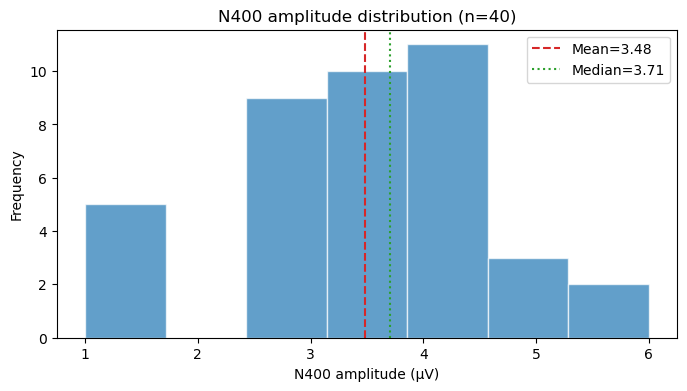

In [16]:
z = make_linear_exact(
    {'ling': abilita_linguaggio},
    {'ling': beta_ling_n400a}, rng_N400, R2_ERP)
n400_amp = np.clip(n400a_mean + n400a_sd * standardize(z), n400a_lo, n400a_hi)

plt.figure(figsize=(8, 4))
plt.hist(n400_amp, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(n400_amp), color='C3', ls='--', label=f'Mean={np.mean(n400_amp):.2f}')
plt.axvline(np.median(n400_amp), color='C2', ls=':', label=f'Median={np.median(n400_amp):.2f}')
plt.xlabel('N400 amplitude (µV)')
plt.ylabel('Frequency')
plt.title(f'N400 amplitude distribution (n={n})')
plt.legend()
plt.show()


### N400 latency

Driven by language ability (−) and age (+). Range 350–500 ms.


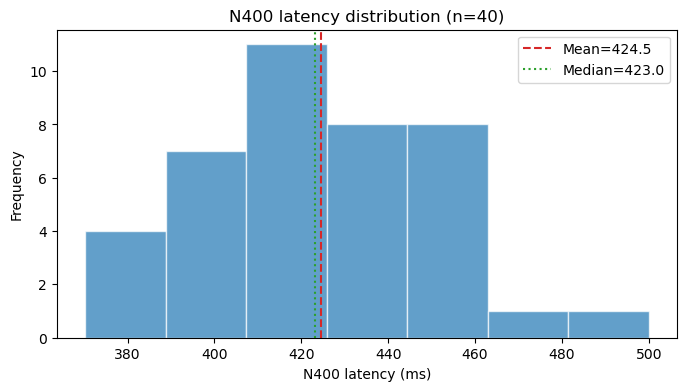

In [17]:
z = make_linear_exact(
    {'ling': abilita_linguaggio, 'age': age},
    {'ling': beta_ling_n400l, 'age': beta_age_n400l}, rng_N400, R2_ERP)
n400_lat = np.clip(n400l_mean + n400l_sd * standardize(z), n400l_lo, n400l_hi)

plt.figure(figsize=(8, 4))
plt.hist(n400_lat, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(n400_lat), color='C3', ls='--', label=f'Mean={np.mean(n400_lat):.1f}')
plt.axvline(np.median(n400_lat), color='C2', ls=':', label=f'Median={np.median(n400_lat):.1f}')
plt.xlabel('N400 latency (ms)')
plt.ylabel('Frequency')
plt.title(f'N400 latency distribution (n={n})')
plt.legend()
plt.show()


### P300 amplitude

Driven by attention ability. Range 5–20 µV.


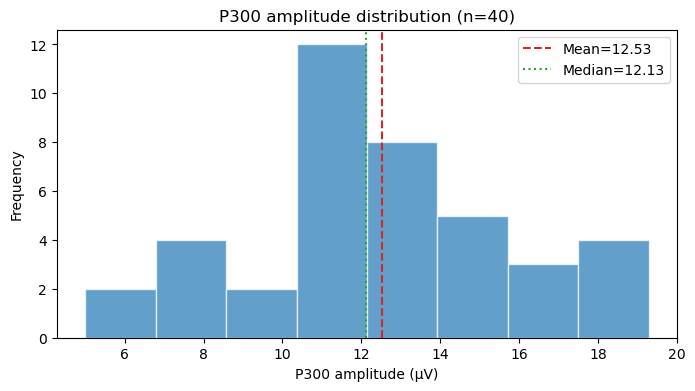

In [18]:
z = make_linear_exact(
    {'attn': abilita_attenzione},
    {'attn': beta_attn_p300a}, rng_P300, R2_ERP)
p300_amp = np.clip(p300a_mean + p300a_sd * standardize(z), p300a_lo, p300a_hi)

plt.figure(figsize=(8, 4))
plt.hist(p300_amp, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(p300_amp), color='C3', ls='--', label=f'Mean={np.mean(p300_amp):.2f}')
plt.axvline(np.median(p300_amp), color='C2', ls=':', label=f'Median={np.median(p300_amp):.2f}')
plt.xlabel('P300 amplitude (µV)')
plt.ylabel('Frequency')
plt.title(f'P300 amplitude distribution (n={n})')
plt.legend()
plt.show()


### P300 latency

Driven by attention ability (−) and age (+). Range 300–450 ms.


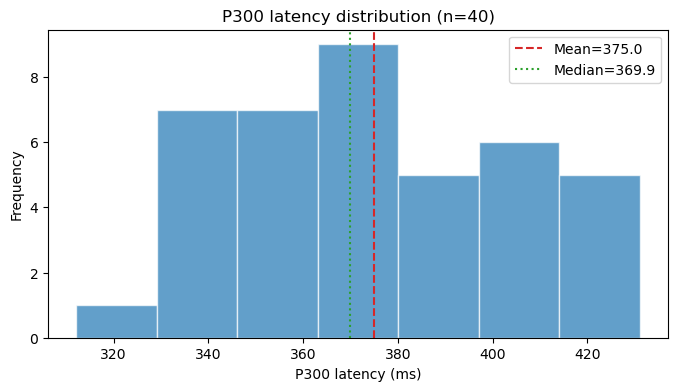

In [19]:
z = make_linear_exact(
    {'attn': abilita_attenzione, 'age': age},
    {'attn': beta_attn_p300l, 'age': beta_age_p300l}, rng_P300, R2_ERP)
p300_lat = np.clip(p300l_mean + p300l_sd * standardize(z), p300l_lo, p300l_hi)

plt.figure(figsize=(8, 4))
plt.hist(p300_lat, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(p300_lat), color='C3', ls='--', label=f'Mean={np.mean(p300_lat):.1f}')
plt.axvline(np.median(p300_lat), color='C2', ls=':', label=f'Median={np.median(p300_lat):.1f}')
plt.xlabel('P300 latency (ms)')
plt.ylabel('Frequency')
plt.title(f'P300 latency distribution (n={n})')
plt.legend()
plt.show()


### APACS

Global language score [0–1], driven by N400 (latency and amplitude),
CRIq, and age.


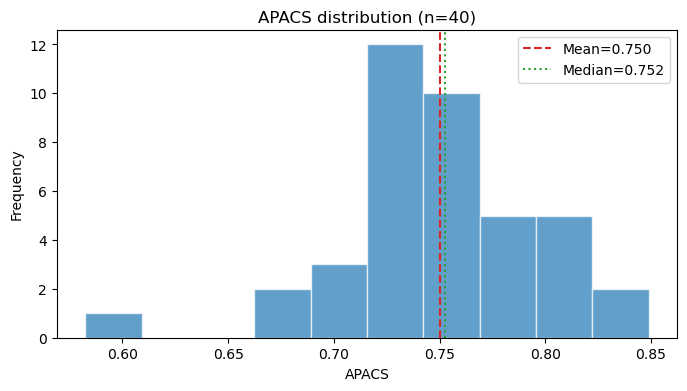

In [20]:
z = make_linear_exact(
    {'n400_lat': n400_lat, 'n400_amp': n400_amp,
     'criq': criq, 'age': age, 'sex': sex},
    apacs_beta, rng_apacs, R2_TEST)
apacs = np.clip(apacs_mean + apacs_sd * standardize(z), apacs_lo, apacs_hi)

plt.figure(figsize=(8, 4))
plt.hist(apacs, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(apacs), color='C3', ls='--', label=f'Mean={np.mean(apacs):.3f}')
plt.axvline(np.median(apacs), color='C2', ls=':', label=f'Median={np.median(apacs):.3f}')
plt.xlabel('APACS')
plt.ylabel('Frequency')
plt.title(f'APACS distribution (n={n})')
plt.legend()
plt.show()


### Attentive Matrix

Attention score [0–60], driven by P300 (latency and amplitude),
CRIq, and age.


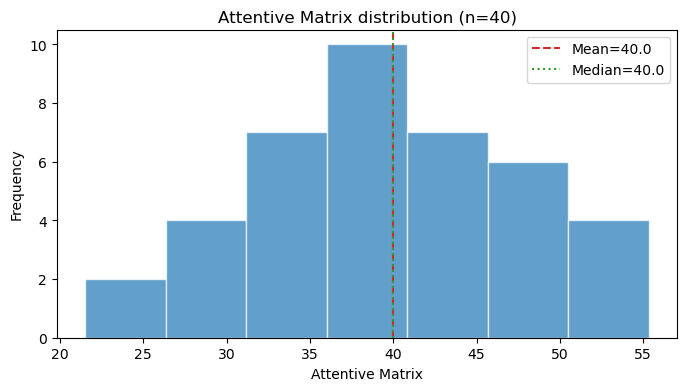

In [21]:
z = make_linear_exact(
    {'p300_lat': p300_lat, 'p300_amp': p300_amp,
     'criq': criq, 'age': age, 'sex': sex},
    matrix_beta, rng_matrix, R2_TEST)
matrix = np.clip(matrix_mean + matrix_sd * standardize(z), matrix_lo, matrix_hi)

plt.figure(figsize=(8, 4))
plt.hist(matrix, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(matrix), color='C3', ls='--', label=f'Mean={np.mean(matrix):.1f}')
plt.axvline(np.median(matrix), color='C2', ls=':', label=f'Median={np.median(matrix):.1f}')
plt.xlabel('Attentive Matrix')
plt.ylabel('Frequency')
plt.title(f'Attentive Matrix distribution (n={n})')
plt.legend()
plt.show()


### MoCA

Montreal Cognitive Assessment [0–30], driven by all four ERP markers,
CRIq, and age.


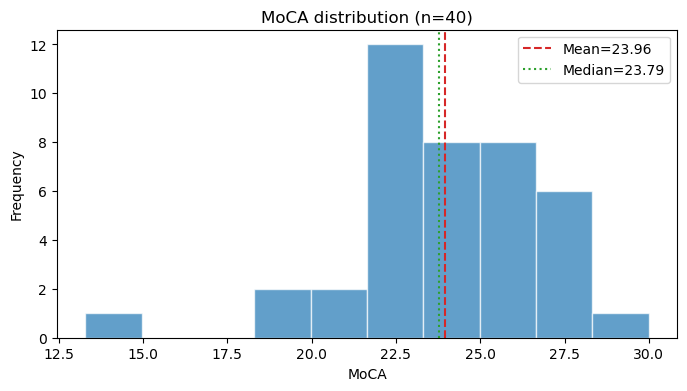

In [22]:
z = make_linear_exact(
    {'n400_lat': n400_lat, 'n400_amp': n400_amp,
     'p300_lat': p300_lat, 'p300_amp': p300_amp,
     'criq': criq, 'age': age, 'sex': sex},
    moca_beta, rng_moca, R2_TEST)
moca = np.clip(moca_mean + moca_sd * standardize(z), moca_lo, moca_hi)

plt.figure(figsize=(8, 4))
plt.hist(moca, bins='auto', edgecolor='white', alpha=0.7)
plt.axvline(np.mean(moca), color='C3', ls='--', label=f'Mean={np.mean(moca):.2f}')
plt.axvline(np.median(moca), color='C2', ls=':', label=f'Median={np.median(moca):.2f}')
plt.xlabel('MoCA')
plt.ylabel('Frequency')
plt.title(f'MoCA distribution (n={n})')
plt.legend()
plt.show()


### Patient DataFrame

Combine all variables into a single DataFrame for export.


In [23]:
subject_ids = [f'sub-{i+1:03d}' for i in range(n)]

df_npsy = pd.DataFrame({
    'subject_id': subject_ids,
    'age': age,
    'sex': sex.astype(int),
    'education': education.astype(int),
    'severity': severity.round(3),
    'criq': criq.round(1),
    'apacs': apacs.round(4),
    'matrix': matrix.round(2),
    'moca': moca.round(2),
})

df_eeg = pd.DataFrame({
    'subject_id': subject_ids,
    'n400_amp': n400_amp.round(3),
    'n400_lat': n400_lat.round(2),
    'p300_amp': p300_amp.round(3),
    'p300_lat': p300_lat.round(2),
})

print(f'NPSY: {df_npsy.shape}')
print(f'EEG : {df_eeg.shape}')
display(df_npsy.head())
display(df_eeg.head())


NPSY: (40, 9)
EEG : (40, 5)


,subject_id,age,sex,education,severity,criq,apacs,matrix,moca
0,sub-001,69,1,13,1.112,90.3,0.7256,37.21,23.85
1,sub-002,60,0,13,1.456,122.9,0.8220,55.34,27.31
2,sub-003,72,0,16,3.617,96.2,0.7263,30.78,23.18
3,sub-004,74,1,18,3.228,114.3,0.7579,30.56,19.44
4,sub-005,53,1,13,1.719,86.0,0.7874,47.26,24.25


,subject_id,n400_amp,n400_lat,p300_amp,p300_lat
0,sub-001,4.165,404.22,13.143,352.56
1,sub-002,3.828,387.88,18.586,333.19
2,sub-003,3.135,416.21,11.310,420.96
3,sub-004,1.220,500.00,8.035,410.68
4,sub-005,5.160,418.78,13.374,368.91


## Relationships between variables

Scatterplots with regression lines and a correlation heatmap
to illustrate the multivariate structure of the dataset.


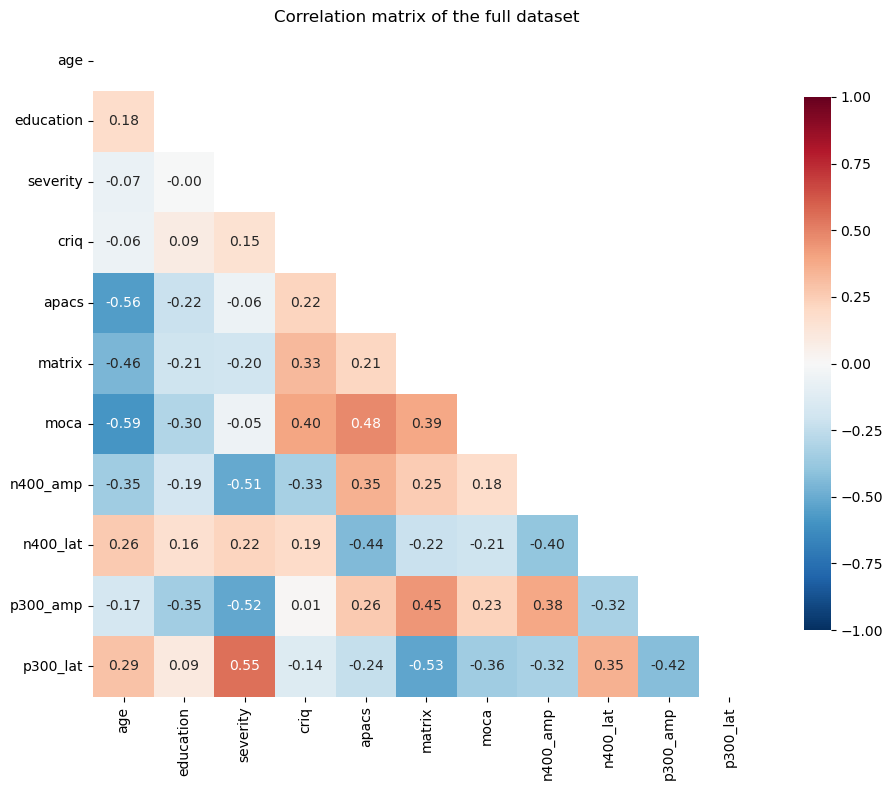

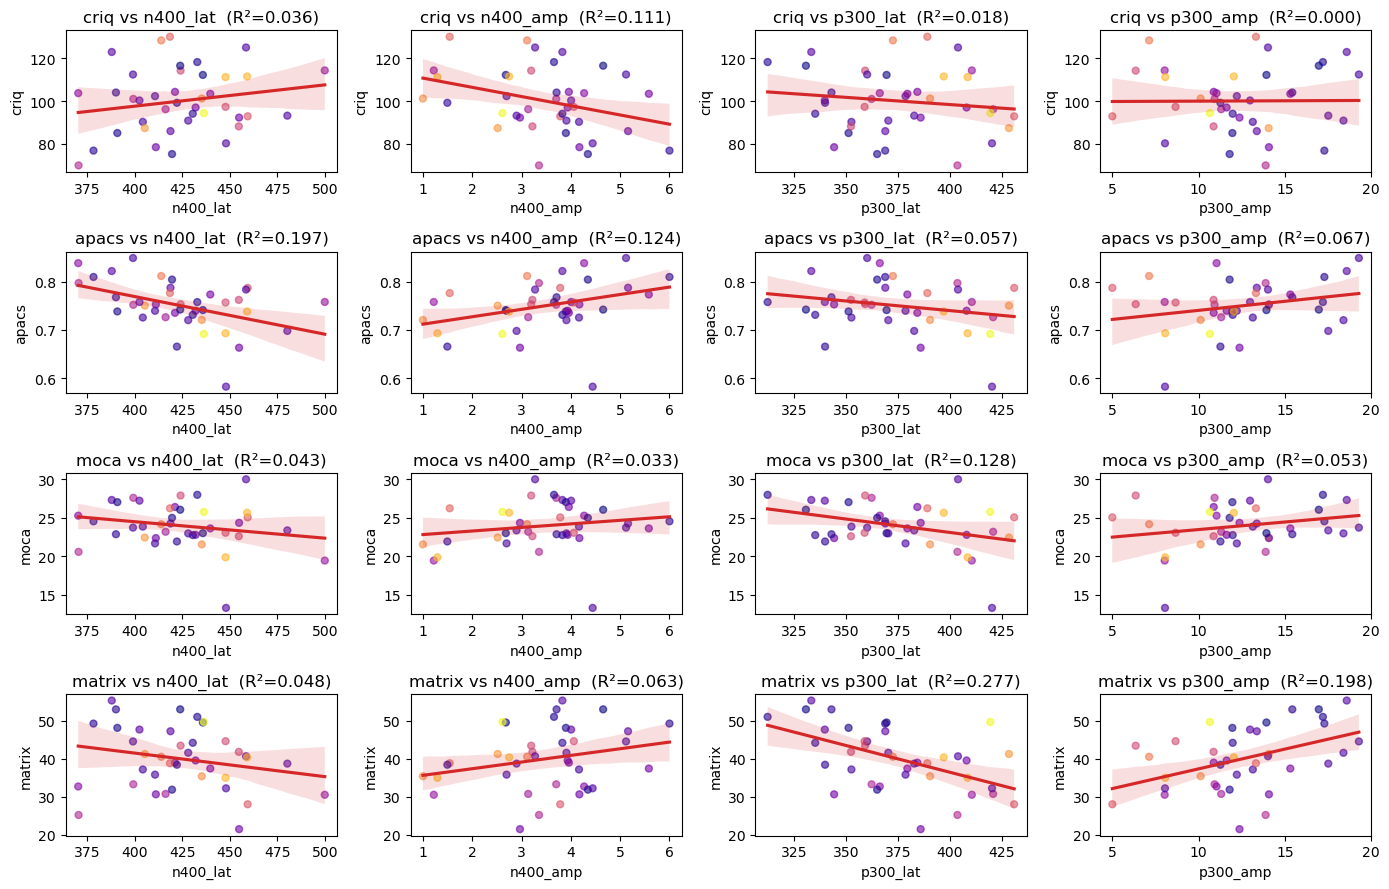

In [24]:
import seaborn as sns

df_plot = df_npsy.merge(df_eeg, on='subject_id')

num = ['age','education','severity','criq',
       'apacs','matrix','moca',
       'n400_amp','n400_lat','p300_amp','p300_lat']

plt.figure(figsize=(10, 8))
corr = df_plot[num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix of the full dataset')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(14, 9))
pairs = [
    ('n400_lat', 'criq'), ('n400_amp', 'criq'), ('p300_lat', 'criq'), ('p300_amp', 'criq'),
    ('n400_lat', 'apacs'), ('n400_amp', 'apacs'), ('p300_lat', 'apacs'), ('p300_amp', 'apacs'),
    ('n400_lat', 'moca'), ('n400_amp', 'moca'), ('p300_lat', 'moca'), ('p300_amp', 'moca'),
    ('n400_lat', 'matrix'), ('n400_amp', 'matrix'), ('p300_lat', 'matrix'), ('p300_amp', 'matrix'),
]
import matplotlib as mpl

sev = df_plot['severity']
norm = mpl.colors.Normalize(vmin=sev.min(), vmax=sev.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap='plasma')
sm.set_array([])

for ax, (x, y) in zip(axes.flat, pairs):
    sns.regplot(data=df_plot, x=x, y=y, ax=ax,
                scatter_kws={'c': sev, 'cmap': 'plasma',
                            'alpha': 0.6, 's': 25,
                            'color': None,
                            'vmin': sev.min(), 'vmax': sev.max()},
                line_kws={'color': 'C3'})
    r2 = np.corrcoef(df_plot[x], df_plot[y])[0, 1]**2
    ax.set_title(f'{y} vs {x}  (R\u00b2={r2:.3f})')

# fig.colorbar(sm, ax=axes.ravel().tolist(), label='Lesion severity')
plt.tight_layout()
plt.show()


### Export to CSV

Save the two datasets for downstream analysis.


In [ ]:
from pathlib import Path

out = Path('../../')
df_npsy.to_csv(out / 'dataset_NPSY.csv', index=False)
df_eeg.to_csv(out / 'dataset_P300.csv', index=False)

print(f'Saved: dataset_NPSY.csv ({df_npsy.shape})')
print(f'Saved: dataset_P300.csv  ({df_eeg.shape})')


Saved: dataset_NPSY.csv ((100, 9))
Saved: dataset_P300.csv  ((100, 5))
